# Activity: QuickCart Delivery Analytics
### Applying Histograms, Density Plots & Proportions to a Real Business Question
Unit 1, Lecture 7 — Visualization of Data, Understanding and Interpretation (UE24CS342AA9)

---

## Scenario

You are a data analyst at **QuickCart**, an online delivery startup. The operations team
has asked you two questions ahead of tomorrow's planning meeting:

1. **"What does our delivery time actually look like?** Are we mostly fast, mostly slow,
   or is something more complicated going on?"
2. **"Which region should we prioritize for extra delivery staff?"**

You've been given delivery records for the last month. Your job is to visualize the data
correctly enough to give the ops team a confident answer — using the same tools from
today's lecture: histograms, bin width, density plots, bandwidth, and proportion charts.

Run the cell below to load your dataset — you do not need to change it.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

# --- QuickCart delivery dataset (synthetic, seeded for reproducibility) ---
rng = np.random.default_rng(42)
n = 1200

regions = rng.choice(["North", "South", "East", "West", "Central"],
                      size=n, p=[0.22, 0.18, 0.22, 0.18, 0.20])

is_express = rng.random(n) < 0.35
delivery_time = np.where(
    is_express,
    rng.normal(loc=5, scale=1.5, size=n),
    rng.normal(loc=18, scale=4.5, size=n),
)
delivery_time = np.clip(delivery_time, 0.5, None)

south_mask = regions == "South"
delivery_time[south_mask] += rng.normal(loc=8, scale=3, size=south_mask.sum())

df = pd.DataFrame({"region": regions, "delivery_time_hours": delivery_time})

def status(t):
    if t <= 8:
        return "On Time"
    elif t <= 20:
        return "Delayed"
    else:
        return "Severely Delayed"

df["delivery_status"] = df["delivery_time_hours"].apply(status)

print(f"Loaded {len(df)} delivery records")
df.head()

Loaded 1200 delivery records


,region,delivery_time_hours,delivery_status
0,West,14.657945,Delayed
1,East,12.668919,Delayed
2,Central,22.652142,Severely Delayed
3,West,10.331552,Delayed
4,North,3.222223,On Time


## Task 1 — Histogram: What does delivery time look like? 

Fill in the blank below to plot a histogram of `delivery_time_hours`. Try **three different
bin widths** by changing the `bins` value: something small (e.g. `50`), something moderate
(e.g. `20`), and something large (e.g. `4`).

**Fill in the blank marked `# TODO`.**

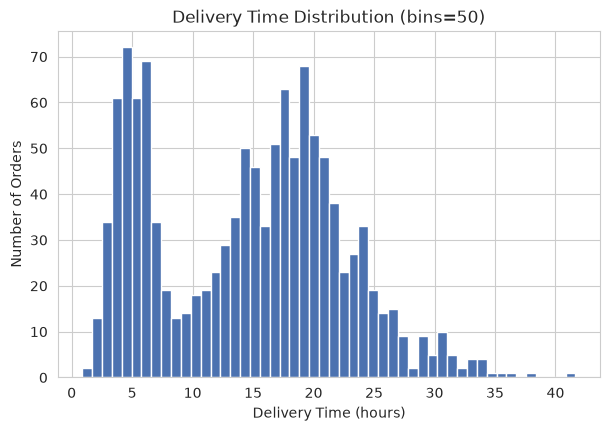

In [13]:
# TODO: set bins to a number of your choice (try 50, then 20, then 4 — re-run each time)
bins = 50  # TODO

plt.figure()
plt.hist(df["delivery_time_hours"], bins=bins, color="#4C72B0", edgecolor="white")
plt.title(f"Delivery Time Distribution (bins={bins})")
plt.xlabel("Delivery Time (hours)")
plt.ylabel("Number of Orders")
plt.show()

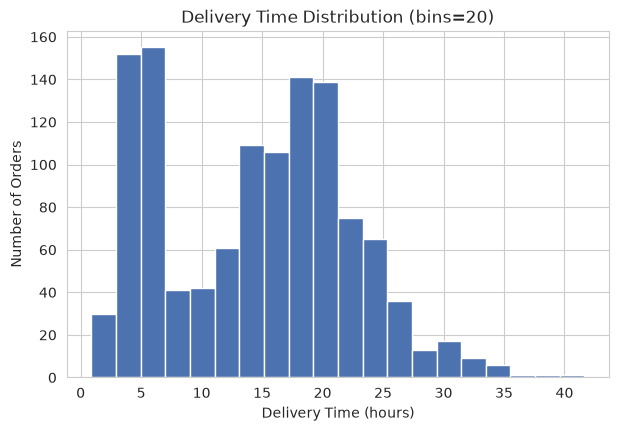

In [14]:
# TODO: set bins to a number of your choice (try 50, then 20, then 4 — re-run each time)
bins = 20  # TODO

plt.figure()
plt.hist(df["delivery_time_hours"], bins=bins, color="#4C72B0", edgecolor="white")
plt.title(f"Delivery Time Distribution (bins={bins})")
plt.xlabel("Delivery Time (hours)")
plt.ylabel("Number of Orders")
plt.show()

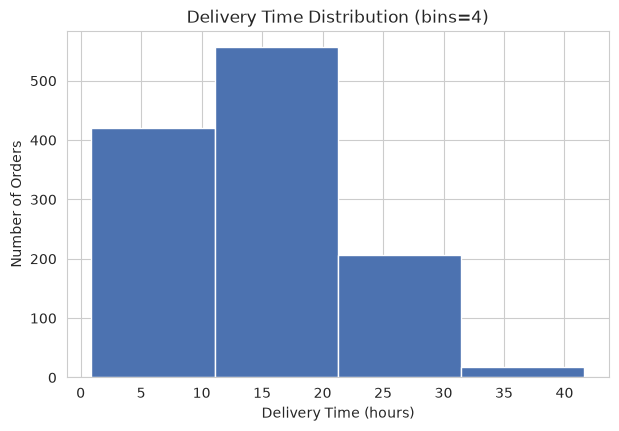

In [15]:
# TODO: set bins to a number of your choice (try 50, then 20, then 4 — re-run each time)
bins = 4 # TODO

plt.figure()
plt.hist(df["delivery_time_hours"], bins=bins, color="#4C72B0", edgecolor="white")
plt.title(f"Delivery Time Distribution (bins={bins})")
plt.xlabel("Delivery Time (hours)")
plt.ylabel("Number of Orders")
plt.show()

**Question 1:** At a bin width that shows the clearest picture, does the data look like
a single smooth hump, or something else? What might explain that shape in a delivery
business (hint: think about whether QuickCart might offer more than one type of delivery
service)?

*At bins=20 the shape is clearly bimodal, not a single smooth hump: one hump around 4-6 hours and a second, wider hump around 15-20 hours. This matches the data-generating logic, QuickCart runs two service tiers (express vs. standard delivery),so the "delivery time" variable is really a mixture of two different processes, not one. At bins=4 this structure disappears into a single blob; at bins=50 it becomes noisy but the two-hump shape is still visible under the noise.*


## Task 2 — Density Plot & Bandwidth 

A histogram's bin width can hide or exaggerate structure. Let's check with a KDE curve,
where **bandwidth** plays the same role as bin width.

**Fill in the blank:** try `bw_adjust` values of `0.2`, `1.0`, and `2.5` (one at a time,
re-running the cell) and observe how the curve changes.

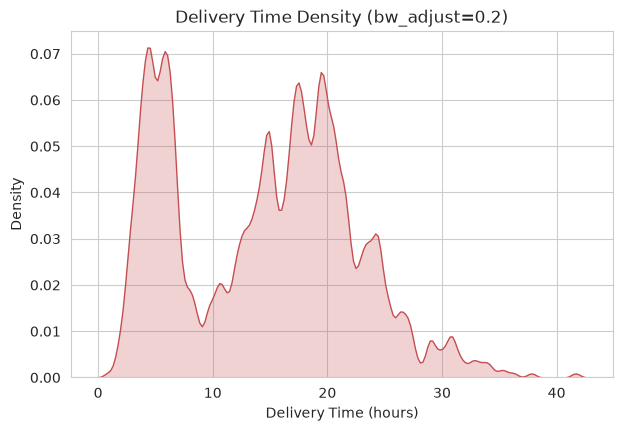

In [16]:
# TODO: set bw_adjust to 0.2, then 1.0, then 2.5 — re-run for each
bw_adjust = 0.2  # TODO

plt.figure()
sns.kdeplot(df["delivery_time_hours"], bw_adjust=bw_adjust, fill=True, color="#C44E52")
plt.title(f"Delivery Time Density (bw_adjust={bw_adjust})")
plt.xlabel("Delivery Time (hours)")
plt.ylabel("Density")
plt.show()

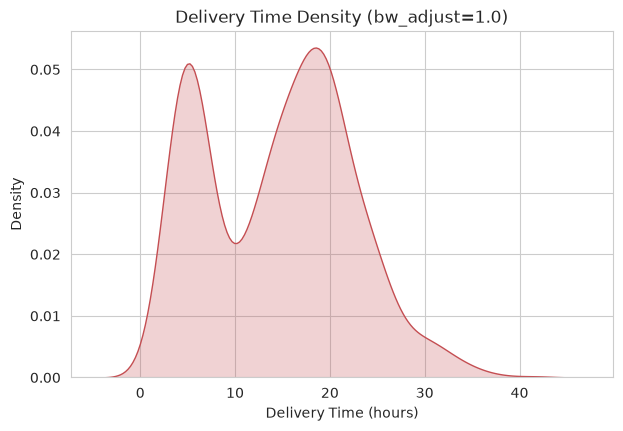

In [17]:
# TODO: set bw_adjust to 0.2, then 1.0, then 2.5 — re-run for each
bw_adjust = 1.0  # TODO

plt.figure()
sns.kdeplot(df["delivery_time_hours"], bw_adjust=bw_adjust, fill=True, color="#C44E52")
plt.title(f"Delivery Time Density (bw_adjust={bw_adjust})")
plt.xlabel("Delivery Time (hours)")
plt.ylabel("Density")
plt.show()

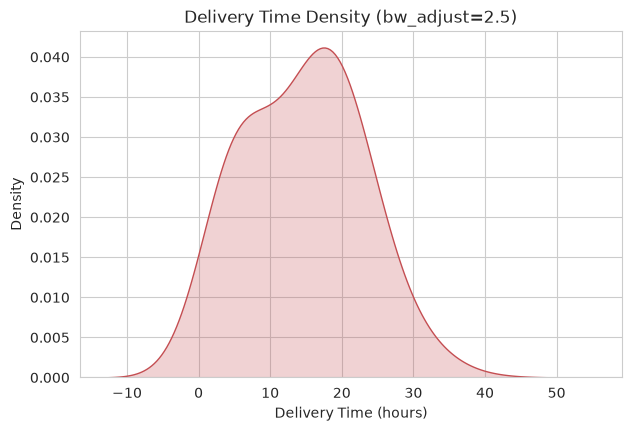

In [18]:
# TODO: set bw_adjust to 0.2, then 1.0, then 2.5 — re-run for each
bw_adjust = 2.5  # TODO

plt.figure()
sns.kdeplot(df["delivery_time_hours"], bw_adjust=bw_adjust, fill=True, color="#C44E52")
plt.title(f"Delivery Time Density (bw_adjust={bw_adjust})")
plt.xlabel("Delivery Time (hours)")
plt.ylabel("Density")
plt.show()

**Question 2:** At which `bw_adjust` value do you clearly see **two peaks** instead of
one? What does each peak most likely represent in QuickCart's delivery operations?
What would happen if an analyst only ever used a large bandwidth here — what business
insight would they miss?

*Two peaks are clearly visible at bw_adjust=0.2 and still visible (softer) at 1.0. The left peak (~5h) represents express deliveries; the right, wider peak (~18-20h, pulled further right by the South region's added delay) represents standard deliveries. At bw_adjust=2.5 the two peaks merge into one smooth hump. An analyst who only ever used a large bandwidth would miss the fact that two operationally distinct delivery types exist in the data, they'd report a single "average delivery time" and design one staffing plan, when in reality express and standard shipments need separate targets and separate resourcing.*


## Task 3 — Proportions: Which region needs help? 

Now let's look at `delivery_status` (On Time / Delayed / Severely Delayed) across regions.

**Fill in the blank:** the code below builds the proportion table and three chart types.
Nothing to change here except reading the output carefully — but try commenting out one of
the three chart types (`axes[0]`, `axes[1]`, or `axes[2]`) to see how the layout responds.

In [19]:
status_by_region = (
    df.groupby("region")["delivery_status"]
    .value_counts(normalize=True)
    .unstack()
    .reindex(columns=["On Time", "Delayed", "Severely Delayed"])
)
status_by_region.round(2)

delivery_status,On Time,Delayed,Severely Delayed
region,,,
Central,0.35,0.41,0.24
East,0.33,0.51,0.16
North,0.38,0.45,0.17
South,0.04,0.42,0.54
West,0.35,0.45,0.20


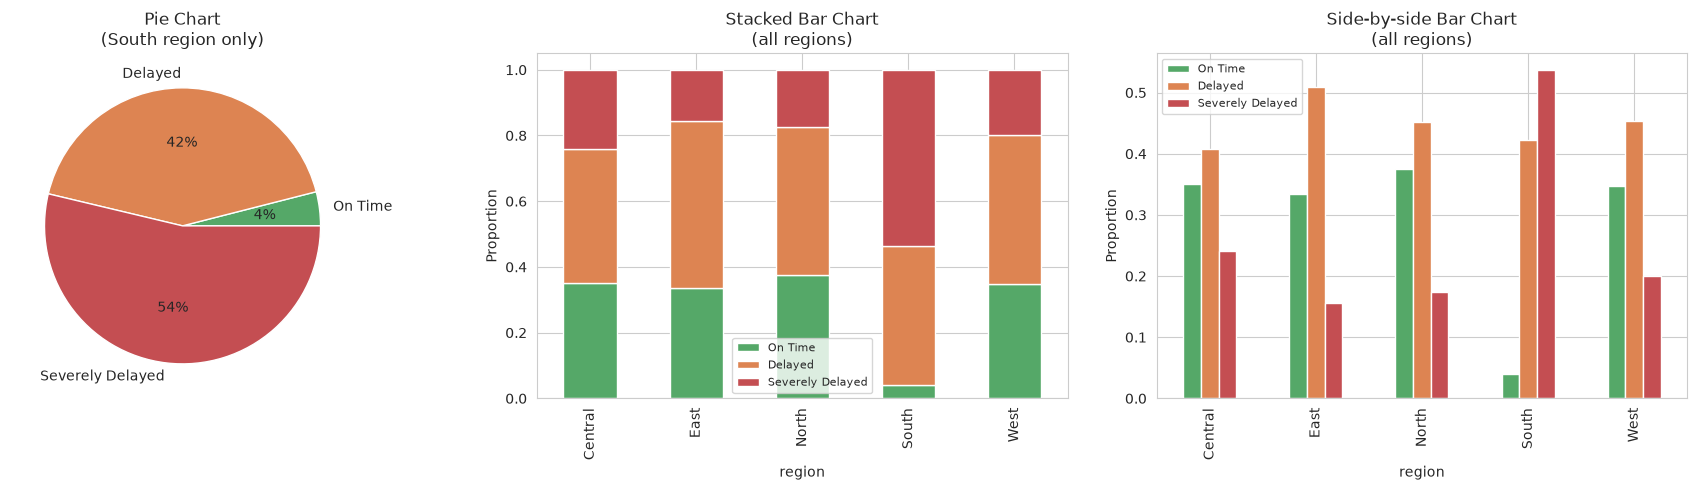

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie chart -- one region only, since pie charts don't compare groups well
axes[0].pie(status_by_region.loc["South"], labels=status_by_region.columns,
            autopct="%1.0f%%", colors=["#55A868", "#DD8452", "#C44E52"])
axes[0].set_title("Pie Chart\n(South region only)")

# Stacked bar -- all regions
status_by_region.plot(kind="bar", stacked=True, ax=axes[1],
                       color=["#55A868", "#DD8452", "#C44E52"])
axes[1].set_title("Stacked Bar Chart\n(all regions)")
axes[1].set_ylabel("Proportion")
axes[1].legend(fontsize=8)

# Side-by-side bar -- all regions
status_by_region.plot(kind="bar", stacked=False, ax=axes[2],
                       color=["#55A868", "#DD8452", "#C44E52"])
axes[2].set_title("Side-by-side Bar Chart\n(all regions)")
axes[2].set_ylabel("Proportion")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Question 3:** Which region has the worst delivery performance, and which chart made
that easiest to spot? Why would the pie chart alone (even one per region) be a poor choice
for comparing all five regions against each other?

*South has by far the worst delivery performance,only ~4% on-time, and over 50% "Severely Delayed," compared to every other region where On Time sits around 33-37% and Severely Delayed stays under 25%.

The side-by-side bar chart makes this easiest to spot: every region's "Severely Delayed" bar starts from the same zero baseline, so South's tall red bar visibly towers over the others at a glance, no mental math needed. The stacked bar chart also shows it (South's chart is clearly "more red"), but it's slightly harder to compare segment sizes since the red segments don't share a common bottom edge across regions.

A pie chart, even one per region, is a poor choice for comparing all five: you'd need five separate pies side by side and would have to compare wedge angles across charts by eye, angle/area judgments are much less precise than comparing bar heights against a shared axis. There's no common baseline linking the five pies, so spotting that South's red wedge is proportionally larger than West's red wedge requires much more visual effort than reading two bar heights off the
same y-axis.*


## Wrap-up — Your Recommendation *(~3 min)*

Write a 2–3 sentence recommendation to the QuickCart ops team, combining **both** findings:
- What Task 1 & 2 revealed about delivery time structure (histogram + KDE + bandwidth)
- What Task 3 revealed about regional performance (proportions)

*QuickCart's delivery times are not a single distribution — they're a mix of two operational modes (express, ~5h; standard, ~18h), so any single "average delivery time" metric hides more than it reveals. Regionally, South is the clear outlier with the worst on-time performance and highest share of severely delayed orders. Recommendation: report delivery time as two separate distributions (express vs. standard) rather than one blended average, and prioritize additional delivery staff in the South region first.*
